In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [3]:
df = pd.read_csv("/Users/pushkal/Downloads/StudentsPerformance copy.csv") 

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [5]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [6]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [7]:
df["Total Score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
)

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Score
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


In [8]:
df["Pass"] = np.where(
    (df["math score"] >= 40) &
    (df["reading score"] >= 40) &
    (df["writing score"] >= 40),
    "Pass",
    "Fail"
)

df["Pass"].value_counts()

Pass
Pass    949
Fail     51
Name: count, dtype: int64

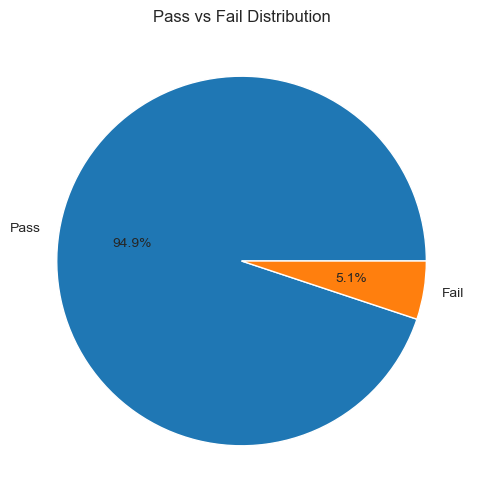

In [9]:
plt.figure(figsize=(6,6))

df["Pass"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Pass vs Fail Distribution")

plt.ylabel("")

plt.show()

In [10]:
subject_means = df[
    ["math score","reading score","writing score"]
].mean()

subject_means

math score       66.089
reading score    69.169
writing score    68.054
dtype: float64

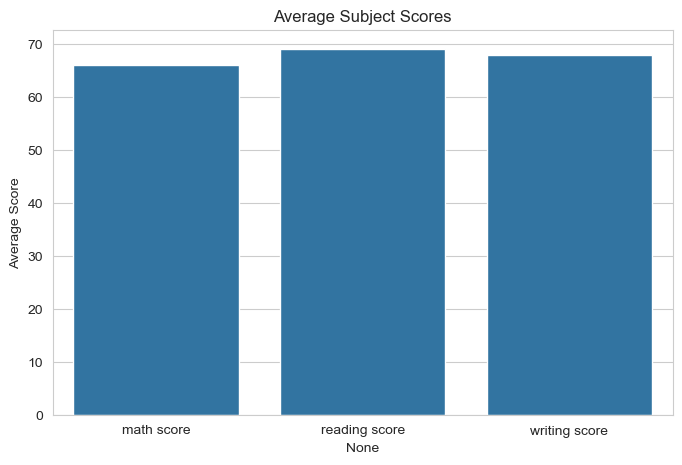

In [11]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=subject_means.index,
    y=subject_means.values
)

plt.title("Average Subject Scores")
plt.ylabel("Average Score")

plt.show()

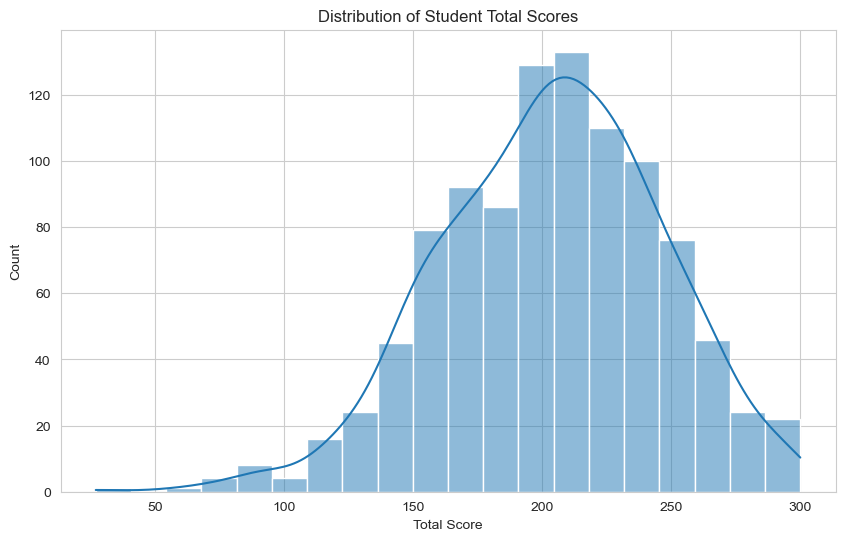

In [12]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Total Score"],
    bins=20,
    kde=True
)

plt.title("Distribution of Student Total Scores")

plt.xlabel("Total Score")

plt.show()

In [13]:
np.random.seed(42)

df["Attendance"] = np.random.randint(60,100,size=len(df))

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Score,Pass,Attendance
0,female,group B,bachelor's degree,standard,none,72,72,74,218,Pass,98
1,female,group C,some college,standard,completed,69,90,88,247,Pass,88
2,female,group B,master's degree,standard,none,90,95,93,278,Pass,74
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,Pass,67
4,male,group C,some college,standard,none,76,78,75,229,Pass,80


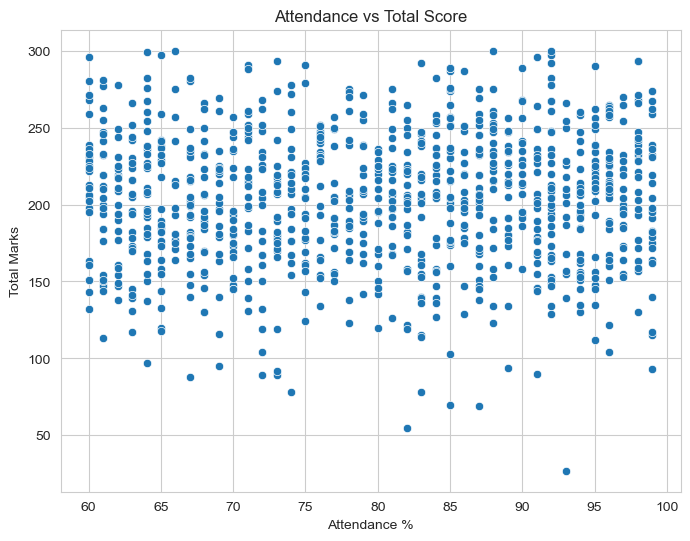

In [14]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Attendance",
    y="Total Score"
)

plt.title("Attendance vs Total Score")

plt.xlabel("Attendance %")
plt.ylabel("Total Marks")

plt.show()

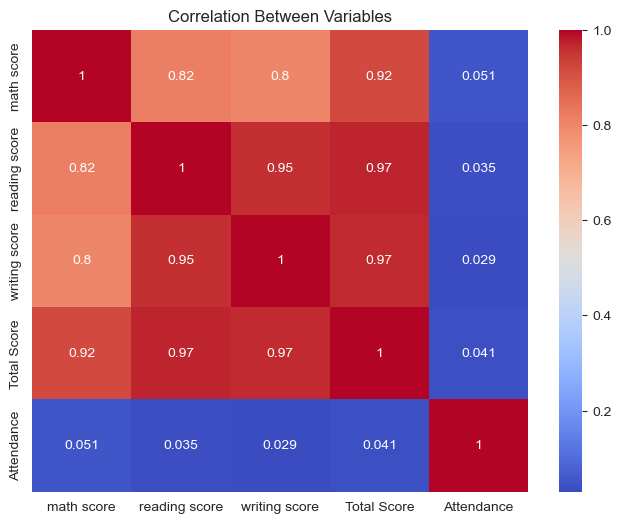

In [15]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Variables")

plt.show()

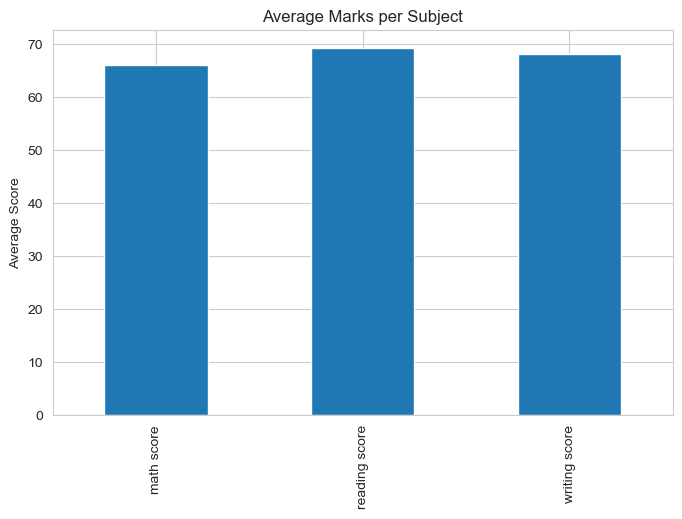

In [16]:
subject_avg = df[
    ["math score","reading score","writing score"]
].mean()

plt.figure(figsize=(8,5))

subject_avg.plot(kind="bar")

plt.title("Average Marks per Subject")

plt.ylabel("Average Score")

plt.show()

In [17]:
high_attendance = df[df["Attendance"] > 85]

avg_high_attendance = high_attendance["Total Score"].mean()

avg_all = df["Total Score"].mean()

print("Average score (all students):", avg_all)

print("Average score (>85% attendance):", avg_high_attendance)

Average score (all students): 203.312
Average score (>85% attendance): 205.77567567567567


In [18]:
increase = (
    (avg_high_attendance - avg_all) /
    avg_all
) * 100

print(f"Students with >85% attendance score {increase:.2f}% higher.")

Students with >85% attendance score 1.21% higher.
